# Functional decoding (NMF clusters)

Exploratory figures for **bilateral** (L+R pooled) multivariate decoding with NMF
functional insula groups (`Sensory` / `Sustain` / `Motor`; k=3), plotted
alongside left-hemisphere anatomical comparison ROIs (`STG`, `SMC`, `MFG`).

Window exports use the `_LR` suffix to mark bilateral functional pools (not left-only).

**Three figure types in this notebook:**

1. **Windowed** — bar panels + confusion matrices from `(decode){datatype}` H5
2. **Time-resolved** — four-phase accuracy curves from `(decode)(resolved){datatype}` H5
3. **Cross-condition generalization** — 2D train×test maps from
   `(cross)(generalized){datatype}` H5 (Repeat → Decision, Delay)

Data roots:
- Functional: this worktree `../results/decoding/{Task}/`
- Comparison ROIs: `anatomical_results_root` (main checkout; legacy `(roi)(bipolar)` layout)

Style follows [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).


In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from mne_bids import BIDSPath
from IPython.display import display
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter, gaussian_filter1d, label as nd_label
from matplotlib.ticker import MaxNLocator

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
gold = '#C4A35A'  # intermediate (NMF k=3)
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'
mfg_color = '#666666'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

## Config

Edit `hue_order`, `hemi`, and `articulator_phoneme_filter` below.
`FIGURE_SPECS` lists task × decode-type combinations for batch export.

In [3]:
ref = 'bipolar'
phases = ['Stimulus', 'Delay', 'Go', 'Response']

hue_order = ['Sensory', 'Sustain', 'Motor', 'STG', 'SMC', 'MFG']
hemi = 'LR'  # bilateral functional pools; anatomical comparison stays Left
description = 'Repeat'
articulator_phoneme_filter = '1'
sig_p = 0.05
resolved_sig_p = 0.01  # cluster-corrected bars on time-resolved traces
smooth_sigma = 2

results_root = Path('..') / 'results' / 'decoding'
anatomical_results_root = Path('/hpc/group/coganlab/nanlinshi/insula/results')
results_roots = [results_root, anatomical_results_root]

from src.paths import img_dir, resolve_decoding_task_root, save_svg
# Figures saved flat under img/decode_functional/ (no subfolders).
export_dir = img_dir('decode_functional')
export_dir.mkdir(parents=True, exist_ok=True)

FIGURE_SPECS = [
    ('LexicalDelay', 'lexicality'),
    ('LexicalDelay', 'lexicality', 'Decision'),
    ('LexicalDelay', 'phoneme'),
    ('LexicalDelay', 'articulator'),
    ('PhonemeSequence', 'phoneme'),
    ('PhonemeSequence', 'articulator'),
]

ROI_COLOR_MAP = {
    'Sensory': blue,           # sensory_transient (NMF)
    'Sustain': red,            # sustain (NMF)
    'Motor': gold,             # motor (NMF)
    'STG': stg_color,
    'SMC': smc_color,
    'MFG': mfg_color,
}

ARTICULATOR_CLASS_LABELS = ['dorsal', 'high', 'labial', 'low']



BILATERAL_FUNCTIONAL = {'Sensory', 'Sustain', 'Motor'}
NNLS_COMPONENTS = {'NNLSSustain', 'NNLSMotor', 'NNLSSensory'}
ANATOMICAL_COMPARISON_ROIS = {'STG', 'SMC', 'MFG', 'AIC', 'PIC'}


def roi_hemi_from_subject(subject: str) -> tuple[str, str]:
    """Map BIDS subject id to plot ROI name and hemi filter key."""
    subject = str(subject)
    if subject in BILATERAL_FUNCTIONAL:
        return subject, 'LR'
    if subject == 'NNLSSensory':
        return 'NNLSSensory', 'LR'
    if subject in {'Sustain', 'Motor'}:
        return subject, 'LR'
    if subject.endswith('l'):
        return subject[:-1], 'Left'
    if subject.endswith('r'):
        return subject[:-1], 'Right'
    return subject, 'LR'


def filter_scores_by_hemi(scores: pd.DataFrame, hemi: str | None) -> pd.DataFrame:
    """Filter score rows by hemi.

    ``hemi='LR'`` keeps bilateral functional pools plus left anatomical
    comparison ROIs so mixed hue_order plots still work.
    """
    if hemi is None or scores.empty:
        return scores
    if hemi == 'LR':
        keep = scores['hemi'].eq('LR') | (
            scores['hemi'].eq('Left') & scores['roi'].isin(ANATOMICAL_COMPARISON_ROIS)
        )
        return scores.loc[keep]
    return scores.loc[scores['hemi'] == hemi]

def parse_figure_spec(spec: tuple) -> tuple[str, str, str]:
    if len(spec) == 2:
        task, decode_type = spec
        return task, decode_type, description
    if len(spec) == 3:
        task, decode_type, spec_description = spec
        return task, decode_type, spec_description
    raise ValueError(f'Invalid FIGURE_SPECS entry: {spec!r}')


def roi_colors_for(rois: list[str]) -> list[str]:
    return [ROI_COLOR_MAP.get(roi, 'gray') for roi in rois]


def spec_suffix(spec_description: str) -> str:
    return '' if spec_description == 'Repeat' else f'_{spec_description}'


def bar_output_name(task: str, decode_type: str, spec_description: str, hemi_label: str) -> str:
    return f'{task}_{decode_type}{spec_suffix(spec_description)}_{hemi_label}.svg'


def confusion_output_name(
    task: str,
    decode_type: str,
    roi: str,
    phase: str,
    spec_description: str,
) -> str:
    return f'{task}_{decode_type}_{roi}_{phase}{spec_suffix(spec_description)}.svg'


## Load windowed decoding results

`load_windowed_decoding()` reads `(decode){datatype}` H5 files for functional pseudo-subjects and returns a long
DataFrame (one row per fold). Summary columns (`accuracy_stable`, `p_value`,
`n_classes`, `h5_path`) are repeated on each fold row.


In [4]:
N_CLASSES = {
    ('phoneme', 'LexicalDelay'): 5,
    ('phoneme', 'PhonemeSequence'): 5,
    ('articulator', 'LexicalDelay'): 4,
    ('articulator', 'PhonemeSequence'): 4,
    ('lexicality', 'LexicalDelay'): 2,
}
_DECODE_TYPE_DEFAULT_N = {
    'phoneme': 5,
    'articulator': 4,
    'lexicality': 2,
}

WINDOW_SCORE_COLUMNS = [
    'fold', 'accuracy', 'accuracy_stable', 'p_value', 'n_classes',
    'roi', 'phase', 'hemi', 'description', 'phoneme', 'datatype', 'h5_path',
]


def chance_level(decode_type: str, task: str, n_classes: int | None = None) -> float:
    """Chance accuracy = 1 / n_classes."""
    if n_classes is not None:
        return 1.0 / n_classes
    n = N_CLASSES.get((decode_type, task))
    if n is None:
        n = _DECODE_TYPE_DEFAULT_N.get(decode_type)
    if n is None:
        warnings.warn(f'Unknown decode_type={decode_type!r}; using n_classes=2')
        n = 2
    return 1.0 / n


def _empty_window_scores() -> pd.DataFrame:
    return pd.DataFrame(columns=WINDOW_SCORE_COLUMNS)


def _h5_window_to_long_df(path) -> pd.DataFrame:
    with h5py.File(path, 'r') as mat:
        accuracy = np.asarray(mat['accuracy'][()], dtype=float)
        accuracy_stable = float(mat['accuracy_stable'][()])
        p_value = float(mat['p_value'][()])
        classes = np.asarray(mat['classes'][()])

    n_folds = accuracy.shape[0]
    n_classes = len(classes)
    roi_name, hemi_label = roi_hemi_from_subject(path.subject)

    df = pd.DataFrame({
        'fold': np.arange(n_folds),
        'accuracy': accuracy,
        'accuracy_stable': accuracy_stable,
        'p_value': p_value,
        'n_classes': n_classes,
        'roi': roi_name,
        'phase': path.processing,
        'hemi': hemi_label,
        'description': path.description,
        'phoneme': path.recording,
        'datatype': path.datatype.replace('(decode)', ''),
        'h5_path': str(path),
    })
    return df


def load_windowed_decoding(
    task: str,
    decode_type: str,
    *,
    ref: str = 'bipolar',
    rois=None,
    hemi: str | None = None,
    description: str | None = None,
    articulator_phoneme_filter: str | None = '1',
    results_root=Path('..') / 'results',
    results_roots=None,
) -> pd.DataFrame:
    """Load windowed decoding scores from `(decode){datatype}` H5 outputs.

    Searches one or more results roots (functional + anatomical comparison).
    """
    roots = list(results_roots) if results_roots is not None else [Path(results_root)]
    paths = []
    for root_base in roots:
        root = resolve_decoding_task_root(root_base, task, ref=ref)
        if root is None:
            warnings.warn(
                f'Missing decoding results directory under {root_base} for task={task}'
            )
            continue
        matched = BIDSPath(
            datatype=f'(decode){decode_type}',
            root=str(root),
            suffix='highgamma',
            check=False,
        ).match()
        paths.extend(matched)

    seen, uniq = set(), []
    for path in paths:
        try:
            key = str(path.fpath.resolve())
        except Exception:
            key = str(path)
        if key not in seen:
            seen.add(key)
            uniq.append(path)
    paths = uniq
    if not paths:
        warnings.warn(
            f'No windowed decoding H5 files for task={task}, decode_type={decode_type}'
        )
        return _empty_window_scores()

    frames = []
    for path in paths:
        try:
            frames.append(_h5_window_to_long_df(path))
        except OSError as exc:
            warnings.warn(f'Skipping unreadable file {path}: {exc}')

    if not frames:
        return _empty_window_scores()

    scores = pd.concat(frames, ignore_index=True)

    if description is not None:
        scores = scores[scores['description'] == description]
    if hemi is not None:
        scores = filter_scores_by_hemi(scores, hemi)
    if rois is not None:
        scores = scores[scores['roi'].isin(rois)]
    if decode_type == 'articulator' and articulator_phoneme_filter is not None:
        scores = scores[scores['phoneme'] == articulator_phoneme_filter]

    return scores.reset_index(drop=True)


def window_summary(scores: pd.DataFrame) -> pd.DataFrame:
    """One row per (roi, phase) with stable accuracy and significance."""
    if scores.empty:
        return pd.DataFrame()
    return (
        scores.groupby(['roi', 'phase'], as_index=False)
        .agg(
            accuracy_stable=('accuracy_stable', 'first'),
            p_value=('p_value', 'first'),
            n_classes=('n_classes', 'first'),
            h5_path=('h5_path', 'first'),
        )
    )



## Plotting functions (windowed)

- `plot_window_accuracy_overview` — 1×4 bar panels with chance dashed line and `*` for `p < 0.05`
- `plot_confusion_matrix` — normalized confusion heatmap from a single H5 path

Time-resolved plotting helpers are defined in the section below.


In [5]:
def _style_axes(ax, *, hide_left: bool = False) -> None:
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if hide_left:
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)


def _overview_ylim(scores: pd.DataFrame, chance: float, pad: float = 0.08) -> tuple[float, float]:
    vals = scores['accuracy'].dropna()
    if vals.empty:
        return 0.0, max(chance * 2, 0.5)
    ymin = max(0.0, float(vals.min()) - pad)
    ymax = max(float(vals.max()) + pad, chance + pad)
    return ymin, ymax


def _add_significance_stars(ax, subset: pd.DataFrame, roi_order: list[str], y_top: float) -> None:
    summary = window_summary(subset)
    if summary.empty:
        return
    sig = summary[summary['p_value'] < sig_p].set_index('roi')
    # With hue=roi, seaborn creates one patch per ROI in order.
    patches = [p for p in ax.patches if p.get_height() > 0 or p.get_width() > 0]
    if len(patches) < len(roi_order):
        patches = list(ax.patches)[:len(roi_order)]
    for i, roi in enumerate(roi_order):
        if roi not in sig.index or i >= len(patches):
            continue
        patch = patches[i]
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height() + patch.get_y() + 0.01
        ax.text(x, min(y, y_top - 0.01), '*', ha='center', va='bottom', fontsize=fontsize)


def plot_window_accuracy_overview(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    roi_order: list[str],
    hemi_label: str,
    chance: float,
    title: str | None = None,
) -> plt.Figure:
    if scores.empty:
        raise ValueError('No decoding scores to plot.')

    present_rois = [r for r in roi_order if r in set(scores['roi'])]
    if not present_rois:
        raise ValueError('No ROI matches in scores for the requested hue_order.')

    ymin, ymax = _overview_ylim(scores, chance)

    fig, axes = plt.subplots(1, len(phases), figsize=(3.0 * len(phases) * cm, 4.0 * cm))
    if len(phases) == 1:
        axes = [axes]
    fig.subplots_adjust(wspace=0.35, bottom=0.32)

    for j, phase in enumerate(phases):
        ax = axes[j]
        if hemi_label == 'LR':
            subset = scores[scores['phase'] == phase]
        else:
            subset = scores[(scores['phase'] == phase) & (scores['hemi'] == hemi_label)]
        phase_rois = [r for r in present_rois if r in set(subset['roi'])]
        phase_palette = roi_colors_for(phase_rois)

        if phase_rois:
            sns.barplot(
                data=subset,
                x='roi',
                y='accuracy',
                hue='roi',
                order=phase_rois,
                hue_order=phase_rois,
                palette=phase_palette,
                legend=False,
                ax=ax,
                errorbar='se',
                capsize=0.08,
                err_kws={'linewidth': 0.75},
                linewidth=0,
            )
            _add_significance_stars(ax, subset, phase_rois, ymax)

        ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
        ax.set_ylim(ymin, ymax)
        ax.set_title(phase, fontsize=fontsize)
        ax.set_xlabel('')
        if j == 0:
            ax.set_ylabel('Accuracy', fontsize=fontsize)
        else:
            ax.set_ylabel('')
        _style_axes(ax, hide_left=(j != 0))
        # Apply after despine/tick_params so rotation is not overwritten.
        ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
        if phase_rois:
            ax.set_xticks(range(len(phase_rois)))
            ax.set_xticklabels(
                phase_rois, rotation=90, ha='center', va='top', fontsize=fontsize,
            )

    if title:
        fig.suptitle(title, fontsize=fontsize, y=1.02)
    return fig


def class_tick_labels(classes: np.ndarray, decode_type: str) -> list[str]:
    classes = np.asarray(classes)
    if decode_type == 'articulator' and len(classes) == len(ARTICULATOR_CLASS_LABELS):
        return ARTICULATOR_CLASS_LABELS
    if decode_type == 'lexicality' and len(classes) == 2:
        return ['class0', 'class1']
    return [str(int(c)) for c in classes]


def load_confusion_from_h5(h5_path: str | Path) -> tuple[np.ndarray, list[str]]:
    with h5py.File(h5_path, 'r') as mat:
        conf = np.asarray(mat['confusion_norm'][()], dtype=float)
        classes = np.asarray(mat['classes'][()])
    return conf, [str(int(c)) for c in classes]


def plot_confusion_matrix(
    h5_path: str | Path,
    *,
    decode_type: str,
    title: str | None = None,
    cmap=reds,
) -> plt.Figure | None:
    h5_path = Path(h5_path)
    if not h5_path.exists():
        warnings.warn(f'Missing H5 for confusion matrix: {h5_path}')
        return None

    with h5py.File(h5_path, 'r') as mat:
        conf = np.asarray(mat['confusion_norm'][()], dtype=float)
        classes = np.asarray(mat['classes'][()])

    labels = class_tick_labels(classes, decode_type)
    n_classes = len(labels)
    chance = 1.0 / n_classes
    vmax = min(1.0, max(0.4, chance * 2.5))

    fig, ax = plt.subplots(figsize=(3.5 * cm, 3 * cm))
    sns.heatmap(
        conf,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        annot_kws={'size': fontsize},
        cbar=True,
        vmin=0.0,
        vmax=vmax,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel('Predicted', fontsize=fontsize)
    ax.set_ylabel('True', fontsize=fontsize)
    if title:
        ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    return fig

## Preview (windowed)


Preview PhonemeSequence/phoneme (Repeat): 100 fold rows | ROIs: ['MFG', 'Motor', 'SMC', 'STG', 'Sensory', 'Sustain'] | chance=0.111


,fold,accuracy,accuracy_stable,p_value,n_classes,roi,phase,hemi,description,phoneme,datatype,h5_path
0,0,0.092593,0.112778,0.875622,9,Motor,Delay,LR,Repeat,1,phoneme,../results/decoding/PhonemeSequence/sub-Motor/...
1,1,0.092593,0.112778,0.875622,9,Motor,Delay,LR,Repeat,1,phoneme,../results/decoding/PhonemeSequence/sub-Motor/...
2,2,0.148148,0.112778,0.875622,9,Motor,Delay,LR,Repeat,1,phoneme,../results/decoding/PhonemeSequence/sub-Motor/...
3,3,0.037037,0.112778,0.875622,9,Motor,Delay,LR,Repeat,1,phoneme,../results/decoding/PhonemeSequence/sub-Motor/...
4,4,0.000000,0.112778,0.875622,9,Motor,Delay,LR,Repeat,1,phoneme,../results/decoding/PhonemeSequence/sub-Motor/...


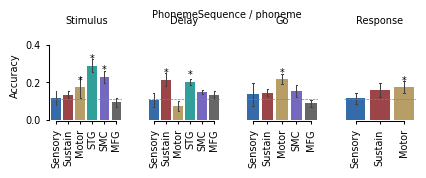

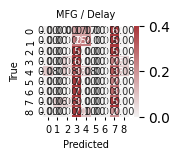

In [6]:
preview_task, preview_decode, preview_description = parse_figure_spec(FIGURE_SPECS[-2])
preview_scores = load_windowed_decoding(
    preview_task,
    preview_decode,
    ref=ref,
    rois=hue_order,
    hemi=hemi,
    description=preview_description,
    articulator_phoneme_filter=articulator_phoneme_filter,
    results_root=results_root,
    results_roots=results_roots,
)

if preview_scores.empty:
    print('No preview data loaded.')
else:
    preview_n_classes = int(preview_scores['n_classes'].iloc[0])
    preview_chance = chance_level(preview_decode, preview_task, n_classes=preview_n_classes)
    print(
        f'Preview {preview_task}/{preview_decode} ({preview_description}): '
        f'{len(preview_scores):,} fold rows | '
        f"ROIs: {sorted(preview_scores['roi'].unique())} | "
        f'chance={preview_chance:.3f}'
    )
    display(preview_scores.head())

    fig = plot_window_accuracy_overview(
        preview_scores,
        phases=phases,
        roi_order=hue_order,
        hemi_label=hemi,
        chance=preview_chance,
        title=f'{preview_task} / {preview_decode}',
    )
    plt.show()

    preview_summary = window_summary(preview_scores)
    if not preview_summary.empty:
        sample = preview_summary.iloc[0]
        fig_cm = plot_confusion_matrix(
            sample['h5_path'],
            decode_type=preview_decode,
            title=f"{sample['roi']} / {sample['phase']}",
        )
        if fig_cm is not None:
            plt.show()


## Batch preview — windowed (inline)

Loops over `FIGURE_SPECS` and displays windowed bar / confusion figures.
File export is commented out below.


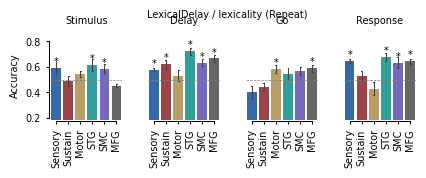

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/LexicalDelay_lexicality_LR.svg


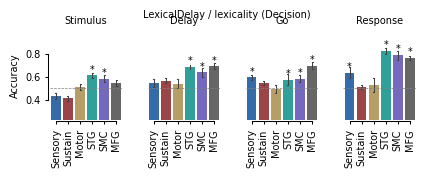

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/LexicalDelay_lexicality_Decision_LR.svg


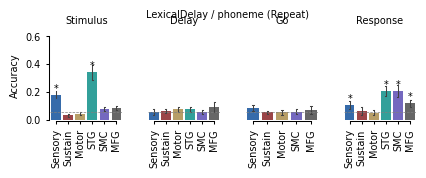

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/LexicalDelay_phoneme_LR.svg


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3621117/3772269303.py:15: UserWarning: Skipping (no data): LexicalDelay / articulator / Repeat
  warnings.warn(f'Skipping (no data): {task} / {decode_type} / {spec_description}')


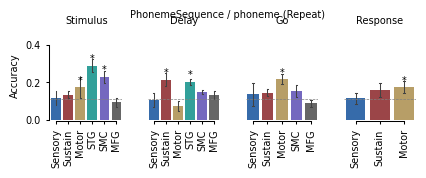

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/PhonemeSequence_phoneme_LR.svg


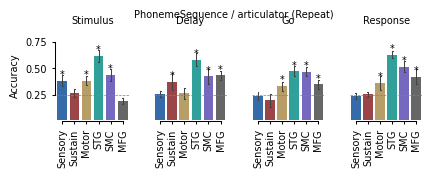

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/PhonemeSequence_articulator_LR.svg


In [7]:
for spec in FIGURE_SPECS:
    task, decode_type, spec_description = parse_figure_spec(spec)
    scores = load_windowed_decoding(
        task,
        decode_type,
        ref=ref,
        rois=hue_order,
        hemi=hemi,
        description=spec_description,
        articulator_phoneme_filter=articulator_phoneme_filter,
        results_root=results_root,
        results_roots=results_roots,
    )
    if scores.empty:
        warnings.warn(f'Skipping (no data): {task} / {decode_type} / {spec_description}')
        continue

    n_classes = int(scores['n_classes'].mode().iloc[0])
    chance = chance_level(decode_type, task, n_classes=n_classes)

    fig = plot_window_accuracy_overview(
        scores,
        phases=phases,
        roi_order=hue_order,
        hemi_label=hemi,
        chance=chance,
        title=f'{task} / {decode_type} ({spec_description})',
    )
    plt.show()

    # --- file export ---
    bar_path = export_dir / bar_output_name(task, decode_type, spec_description, hemi)
    save_svg(fig, bar_path)
    print('Saved', bar_path.with_suffix('.svg'))

    # Confusion matrices: use the Preview cell, or re-enable export below.
    # summary = window_summary(scores)
    # for _, row in summary.iterrows():
    #     ...


## Time-resolved decoding

Four-phase accuracy line plots (Stimulus → Response), same style as
`vizpub/fig3_functional.ipynb` / anatomical Fig 3 Panel A.

Data: `(decode)(resolved){datatype}` H5 under functional + anatomical `results_roots`.
Significance bars mark cluster-corrected `p < resolved_sig_p` (default 0.01) on `fold == 1`.


In [8]:
def phase_accuracy_bar_params(decode_type: str, task: str) -> tuple[float, float]:
    """Significance-bar strip pad and bar height from legacy fig3 notebooks."""
    n = N_CLASSES.get((decode_type, task))
    if n is None:
        n = _DECODE_TYPE_DEFAULT_N.get(decode_type, 2)
    if decode_type == 'lexicality':
        return 0.01, 0.02
    if n >= 5:
        return 0.03, 0.02
    return 0.03, 0.01


def phase_accuracy_data_ylim(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    hue_order: list[str],
    hemi: str,
    ymin_pad: float = 0.1,
    ymax_pad: float = 0.1,
) -> tuple[float, float]:
    """Data-driven ymin/ymax from accuracy values actually plotted."""
    subset = filter_scores_by_hemi(scores, hemi)
    subset = subset[
        subset['phase'].isin(phases)
        & subset['roi'].isin(hue_order)
    ]
    acc = subset['accuracy'].dropna()
    if acc.empty:
        raise ValueError('No accuracy values for y-axis limits.')
    ymin = max(0.0, float(acc.min()) - ymin_pad)
    ymax = float(acc.max()) + ymax_pad
    return ymin, ymax


SCORE_COLUMNS = [
    'time', 'fold', 'accuracy', 'baseline', 'p_value', 'mask',
    'roi', 'phase', 'hemi', 'description', 'phoneme', 'datatype', 'band',
]


def _empty_scores() -> pd.DataFrame:
    return pd.DataFrame(columns=SCORE_COLUMNS)


def _h5_to_long_df(path, smooth_sigma: float = 2) -> pd.DataFrame:
    from scipy.ndimage import gaussian_filter1d

    with h5py.File(path, 'r') as mat:
        accuracy = mat['accuracy'][()]
        time = mat['time'][()]
        p_value = mat['p_values'][()]
        baseline = mat['baseline'][()]
        mask = mat['mask'][()] if 'mask' in mat else None

    n_time, n_fold = accuracy.shape
    baseline_mean = baseline.mean(axis=-1)

    accuracy = gaussian_filter1d(
        accuracy, sigma=smooth_sigma, axis=0, mode='nearest',
    )

    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    df_acc = df_acc.melt(id_vars='time', var_name='fold', value_name='accuracy')
    df_base = df_base.melt(id_vars='time', var_name='fold', value_name='baseline')
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    if mask is not None:
        df_p['mask'] = mask.astype(bool)
    df = df.merge(df_p, on='time', how='left')

    roi_name, hemi_label = roi_hemi_from_subject(path.subject)
    df['roi'] = roi_name
    df['phase'] = path.processing
    df['hemi'] = hemi_label
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype
    df['band'] = path.suffix
    return df


def load_resolved_decoding(
    task: str,
    decode_type: str,
    *,
    ref: str = 'bipolar',
    rois=None,
    hemi: str | None = None,
    description: str | None = None,
    articulator_phoneme_filter: str | None = '1',
    smooth_sigma: float = 2,
    results_root=Path('..') / 'results',
    results_roots=None,
) -> pd.DataFrame:
    """Load time-resolved decoding scores from resolved H5 outputs.

    Searches one or more results roots (functional + anatomical comparison).
    """
    roots = list(results_roots) if results_roots is not None else [Path(results_root)]
    paths = []
    for root_base in roots:
        root = resolve_decoding_task_root(root_base, task, ref=ref)
        if root is None:
            warnings.warn(
                f'Missing decoding results directory under {root_base} for task={task}'
            )
            continue
        matched = BIDSPath(
            datatype=f'(decode)(resolved){decode_type}',
            root=str(root),
            suffix='highgamma',
            check=False,
        ).match()
        paths.extend(matched)

    seen, uniq = set(), []
    for path in paths:
        try:
            key = str(path.fpath.resolve())
        except Exception:
            key = str(path)
        if key not in seen:
            seen.add(key)
            uniq.append(path)
    paths = uniq
    if not paths:
        warnings.warn(
            f'No resolved decoding H5 files for task={task}, decode_type={decode_type}'
        )
        return _empty_scores()

    frames = []
    for path in paths:
        try:
            frames.append(_h5_to_long_df(path, smooth_sigma=smooth_sigma))
        except OSError as exc:
            warnings.warn(f'Skipping unreadable file {path}: {exc}')

    if not frames:
        return _empty_scores()

    scores = pd.concat(frames, ignore_index=True)

    if description is not None:
        scores = scores[scores['description'] == description]

    if hemi is not None:
        scores = filter_scores_by_hemi(scores, hemi)

    if rois is not None:
        scores = scores[scores['roi'].isin(rois)]

    if decode_type == 'articulator' and articulator_phoneme_filter is not None:
        scores = scores[scores['phoneme'] == articulator_phoneme_filter]

    return scores.reset_index(drop=True)



## Plotting functions (time-resolved)

`plot_phase_accuracy` — 1×4 line panels with ROI-colored traces and significance bars.


In [15]:
from matplotlib.ticker import MaxNLocator


def plot_phase_accuracy(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    hue_order: list[str],
    hemi: str = 'LR',
    chance: float | None = None,
    decode_type: str | None = None,
    task: str | None = None,
    roi_colors=None,
    xlim: tuple[float, float] = (-0.5, 1.5),
    ymax: float | None = None,
    ymin: float | None = None,
    pad: float | None = None,
    bar_h: float | None = None,
    sig_p: float = 0.01,
    sig_fold: int = 1,
    legend_panel: int | None = None,
    xlabel_panel: int | None = None,
):
    """Four-phase decoding accuracy figure (publication style, legacy fig3)."""
    if scores.empty:
        raise ValueError('No decoding scores to plot. Check results paths and parameters.')

    if chance is None:
        if decode_type is None or task is None:
            raise ValueError('Provide chance or both decode_type and task.')
        chance = chance_level(decode_type, task)
    if ymin is None or ymax is None:
        data_ymin, data_ymax = phase_accuracy_data_ylim(
            scores, phases=phases, hue_order=hue_order, hemi=hemi,
        )
        ymin = data_ymin if ymin is None else ymin
        ymax = data_ymax if ymax is None else ymax
    if pad is None or bar_h is None:
        if decode_type is None or task is None:
            raise ValueError('Provide pad/bar_h or both decode_type and task.')
        default_pad, default_bar_h = phase_accuracy_bar_params(decode_type, task)
        pad = default_pad if pad is None else pad
        bar_h = default_bar_h if bar_h is None else bar_h

    roi_colors = roi_colors or roi_colors_for(hue_order)
    n_phases = len(phases)
    legend_panel = n_phases // 2 if legend_panel is None else legend_panel
    xlabel_panel = n_phases // 2 if xlabel_panel is None else xlabel_panel
    y_top = ymax + pad + len(hue_order) * (bar_h + 0.005) + 0.02

    fig, axes = plt.subplots(1, n_phases, figsize=(2.5 * n_phases * cm, 3 * cm))
    if n_phases == 1:
        axes = [axes]

    plt.subplots_adjust(wspace=-0.1)

    for j, phase in enumerate(phases):
        ax = axes[j]
        if hemi == 'LR':
            subset = scores[scores.phase == phase]
        else:
            subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]

        sns.lineplot(
            data=subset,
            x='time', y='accuracy', hue='roi',
            palette=roi_colors, hue_order=hue_order,
            lw=1, ax=ax, legend=(j == legend_panel),
        )
        ax.set_autoscale_on(False)
        ax.margins(y=0)

        for k, roi in enumerate(hue_order):
            roi_data = subset[(subset.roi == roi) & (subset.fold == sig_fold)].sort_values('time')
            if roi_data.empty:
                continue
            if 'mask' in roi_data.columns and roi_data['mask'].notna().any():
                mask = roi_data['mask'].values.astype(bool)
            else:
                mask = roi_data['p_value'].values < sig_p
            offset = k * (bar_h + 0.005)
            if mask.any():
                ax.fill_between(
                    roi_data['time'].values,
                    ymax + pad + offset,
                    ymax + pad + bar_h + offset,
                    where=mask,
                    color=roi_colors[k],
                    alpha=1,
                    step='mid',
                    linewidth=0,
                )

    for j, phase in enumerate(phases):
        ax = axes[j]
        ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
        ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
        ax.set_xlim(*xlim)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(phase.capitalize(), fontsize=fontsize)

        if j == 0:
            ax.set_ylabel('Accuracy', fontsize=fontsize)

    axes[xlabel_panel].set_xlabel('Time (s)', fontsize=fontsize)
    if axes[legend_panel].get_legend() is not None:
        axes[legend_panel].legend(fontsize=fontsize)

    for ax in axes:
        sns.despine(ax=ax, trim=True, offset=0.1)

    for ax in axes[1:]:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_ylabel('')

    axes[0].yaxis.set_tick_params(labelleft=True)
    axes[0].yaxis.set_visible(True)

    for ax in axes:
        ax.set_ylim(ymin, y_top)
        ax.set_ybound(ymin, y_top)

    axes[0].yaxis.set_major_locator(MaxNLocator(nbins=3))

    return fig, axes


### Preview (time-resolved)


Time-resolved preview LexicalDelay/lexicality (Repeat): 6,960 rows | ROIs: ['MFG', 'Motor', 'SMC', 'STG', 'Sensory', 'Sustain'] | chance=0.500
Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/resolved_LexicalDelay_lexicality.svg


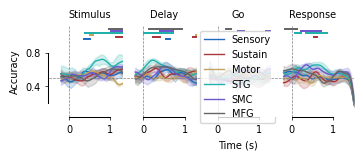

,time,fold,accuracy,baseline,p_value,mask,roi,phase,hemi,description,phoneme,datatype,band
0,-0.20,0,0.487087,0.503382,0.373134,False,Motor,Delay,LR,Repeat,None,(decode)(resolved)lexicality,highgamma
1,-0.17,0,0.489080,0.497941,0.134328,False,Motor,Delay,LR,Repeat,None,(decode)(resolved)lexicality,highgamma
2,-0.14,0,0.486958,0.506324,0.223881,False,Motor,Delay,LR,Repeat,None,(decode)(resolved)lexicality,highgamma
3,-0.11,0,0.483362,0.497353,0.935323,False,Motor,Delay,LR,Repeat,None,(decode)(resolved)lexicality,highgamma
4,-0.08,0,0.482946,0.497500,0.815920,False,Motor,Delay,LR,Repeat,None,(decode)(resolved)lexicality,highgamma


In [10]:
preview_task, preview_decode, preview_description = parse_figure_spec(FIGURE_SPECS[0])
resolved_scores = load_resolved_decoding(
    preview_task,
    preview_decode,
    ref=ref,
    rois=hue_order,
    hemi=hemi,
    description=preview_description,
    articulator_phoneme_filter=articulator_phoneme_filter,
    smooth_sigma=smooth_sigma,
    results_root=results_root,
    results_roots=results_roots,
)

if resolved_scores.empty:
    print('Skipping time-resolved preview: no decoding data loaded.')
else:
    print(
        f'Time-resolved preview {preview_task}/{preview_decode} ({preview_description}): '
        f'{len(resolved_scores):,} rows | '
        f'ROIs: {sorted(resolved_scores.roi.unique())} | '
        f'chance={chance_level(preview_decode, preview_task):.3f}'
    )
    preview_ymin, preview_ymax = phase_accuracy_data_ylim(
        resolved_scores, phases=phases, hue_order=hue_order, hemi=hemi,
    )
    preview_pad, preview_bar_h = phase_accuracy_bar_params(preview_decode, preview_task)
    fig, axes = plot_phase_accuracy(
        resolved_scores,
        phases=phases,
        hue_order=hue_order,
        hemi=hemi,
        decode_type=preview_decode,
        task=preview_task,
        roi_colors=roi_colors_for(hue_order),
        ymin=preview_ymin,
        ymax=preview_ymax,
        pad=preview_pad,
        bar_h=preview_bar_h,
        sig_p=resolved_sig_p,
    )
    save_svg(fig, export_dir / f'resolved_{preview_task}_{preview_decode}')
    print('Saved', export_dir / f'resolved_{preview_task}_{preview_decode}.svg')
    plt.show()
    display(resolved_scores.head())


## Batch preview — time-resolved (inline)

Loops over `FIGURE_SPECS` and displays time-resolved accuracy curves.


Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/resolved_LexicalDelay_lexicality.svg
Time-resolved LexicalDelay/lexicality (Repeat)


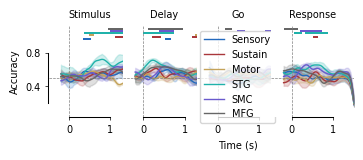

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/resolved_LexicalDelay_lexicality_Decision.svg
Time-resolved LexicalDelay/lexicality (Decision)


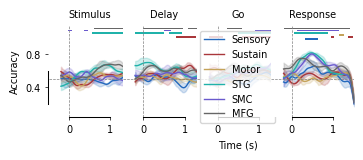

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/resolved_LexicalDelay_phoneme.svg
Time-resolved LexicalDelay/phoneme (Repeat)


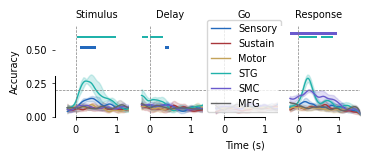

Skip time-resolved LexicalDelay/articulator (Repeat): no data
Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/resolved_PhonemeSequence_phoneme.svg
Time-resolved PhonemeSequence/phoneme (Repeat)


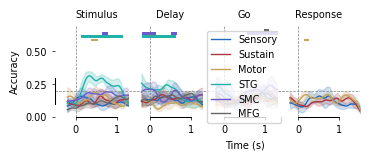

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/decode_functional/resolved_PhonemeSequence_articulator.svg
Time-resolved PhonemeSequence/articulator (Repeat)


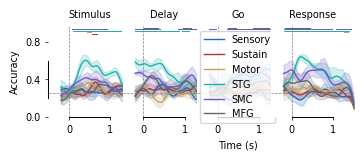

In [16]:
for spec in FIGURE_SPECS:
    task, decode_type, spec_description = parse_figure_spec(spec)
    scores = load_resolved_decoding(
        task,
        decode_type,
        ref=ref,
        rois=hue_order,
        hemi=hemi,
        description=spec_description,
        articulator_phoneme_filter=articulator_phoneme_filter,
        smooth_sigma=smooth_sigma,
        results_root=results_root,
        results_roots=results_roots,
    )
    if scores.empty:
        print(f'Skip time-resolved {task}/{decode_type} ({spec_description}): no data')
        continue

    ymin, ymax = phase_accuracy_data_ylim(
        scores, phases=phases, hue_order=hue_order, hemi=hemi,
    )
    pad, bar_h = phase_accuracy_bar_params(decode_type, task)
    fig, axes = plot_phase_accuracy(
        scores,
        phases=phases,
        hue_order=hue_order,
        hemi=hemi,
        decode_type=decode_type,
        task=task,
        roi_colors=roi_colors_for(hue_order),
        ymin=ymin,
        ymax=ymax,
        pad=pad,
        bar_h=bar_h,
        sig_p=resolved_sig_p,
    )
    out = export_dir / (
        f'resolved_{task}_{decode_type}'
        + ('' if spec_description == 'Repeat' else f'_{spec_description}')
    )
    save_svg(fig, out)
    print('Saved', Path(str(out)).with_suffix('.svg'))
    print(f'Time-resolved {task}/{decode_type} ({spec_description})')
    plt.show()

## Cross-condition generalization (Repeat → Decision)

2D temporal generalization from `(cross)(generalized)lexicality` H5
(adapted from `viz/fig3.ipynb` Cross Decode).

Functional results already on disk for Delay-phase **Repeat → Decision**:

`results/decoding/LexicalDelay/sub-{Sensory,Sustain,Motor}/(cross)(generalized)lexicality/`

Plots:
1. Per-cluster accuracy heatmaps (`plot_cross_2d_generalization`)
2. Multi-cluster significant-cluster overlay (`plot_cross_overlay`)


In [12]:
CROSS_SCORE_COLUMNS = [
    'train_time', 'test_time', 'fold', 'accuracy', 'p_value', 'baseline',
    'roi', 'phase', 'hemi', 'train_on', 'test_on', 'datatype', 'band',
]


def _empty_cross_scores() -> pd.DataFrame:
    return pd.DataFrame(columns=CROSS_SCORE_COLUMNS)


def _h5_cross_to_long_df(path, *, smooth_sigma: float = 1.0) -> pd.DataFrame:
    """Load one cross-generalized H5 into a long table.

    Functional outputs store FDR maps as `p_values`; older fig3 caches used
    `p_values_cluster` — accept either.
    """
    with h5py.File(path, 'r') as mat:
        accuracy = np.asarray(mat['scores'][()], dtype=float)
        train_time = np.asarray(mat['train_time'][()], dtype=float)
        test_time = np.asarray(mat['test_time'][()], dtype=float)
        baseline = np.asarray(mat['baseline'][()], dtype=float)
        if 'p_values_cluster' in mat:
            p_map = np.asarray(mat['p_values_cluster'][()], dtype=float)
        else:
            p_map = np.asarray(mat['p_values'][()], dtype=float)

    n_train, n_test, n_fold = accuracy.shape
    # baseline: (n_train, n_test, n_perm, n_fold) → mean over perm, then later fold
    baseline_mean = baseline.mean(axis=2)

    if smooth_sigma and smooth_sigma > 0:
        accuracy = gaussian_filter(
            accuracy, sigma=(smooth_sigma, smooth_sigma, 0), mode='nearest',
        )

    Ttrain, Ttest = np.meshgrid(train_time, test_time, indexing='ij')
    df_acc = pd.DataFrame(
        accuracy.reshape(-1, n_fold), columns=range(n_fold),
    )
    df_acc['train_time'] = Ttrain.flatten()
    df_acc['test_time'] = Ttest.flatten()
    df_acc = df_acc.melt(
        id_vars=['train_time', 'test_time'],
        var_name='fold',
        value_name='accuracy',
    )

    df_p = pd.DataFrame({
        'train_time': Ttrain.flatten(),
        'test_time': Ttest.flatten(),
        'p_value': p_map.reshape(-1),
    })
    df_base = pd.DataFrame({
        'train_time': Ttrain.flatten(),
        'test_time': Ttest.flatten(),
        'baseline': baseline_mean.mean(axis=2).reshape(-1),
    })
    df = df_acc.merge(df_p, on=['train_time', 'test_time'], how='left')
    df = df.merge(df_base, on=['train_time', 'test_time'], how='left')

    roi_name, hemi_label = roi_hemi_from_subject(path.subject)
    desc = path.description or ''
    if '2' in desc:
        train_on, test_on = desc.split('2', 1)
    else:
        train_on = test_on = desc

    roi_name, hemi_label = roi_hemi_from_subject(path.subject)
    df['roi'] = roi_name
    df['phase'] = path.processing
    df['hemi'] = hemi_label
    df['train_on'] = train_on
    df['test_on'] = test_on
    df['datatype'] = path.datatype.replace('(cross)(generalized)', '')
    df['band'] = path.suffix
    return df


def load_cross_generalized_decoding(
    task: str,
    decode_type: str,
    *,
    ref: str = 'bipolar',
    rois=None,
    hemi: str | None = None,
    phase: str | None = None,
    train_on: str | None = None,
    test_on: str | None = None,
    smooth_sigma: float = 1.0,
    results_root=Path('..') / 'results',
    results_roots=None,
) -> pd.DataFrame:
    """Load 2D cross-condition generalization scores.

    Searches one or more results roots (functional + anatomical comparison).
    """
    roots = list(results_roots) if results_roots is not None else [Path(results_root)]
    paths = []
    for root_base in roots:
        root = resolve_decoding_task_root(root_base, task, ref=ref)
        if root is None:
            warnings.warn(
                f'Missing decoding results directory under {root_base} for task={task}'
            )
            continue
        matched = BIDSPath(
            datatype=f'(cross)(generalized){decode_type}',
            root=str(root),
            suffix='highgamma',
            check=False,
        ).match()
        paths.extend(matched)

    seen, uniq = set(), []
    for path in paths:
        try:
            key = str(path.fpath.resolve())
        except Exception:
            key = str(path)
        if key not in seen:
            seen.add(key)
            uniq.append(path)
    paths = uniq

    if not paths:
        warnings.warn(
            f'No cross-generalized H5 for task={task}, decode_type={decode_type}'
        )
        return _empty_cross_scores()

    frames = []
    for path in tqdm(paths, desc=f'cross {task}/{decode_type}'):
        try:
            frames.append(_h5_cross_to_long_df(path, smooth_sigma=smooth_sigma))
        except OSError as exc:
            warnings.warn(f'Skipping unreadable file {path}: {exc}')

    if not frames:
        return _empty_cross_scores()

    scores = pd.concat(frames, ignore_index=True)

    if hemi is not None:
        scores = filter_scores_by_hemi(scores, hemi)
    if rois is not None:
        scores = scores[scores['roi'].isin(rois)]
    if phase is not None:
        scores = scores[scores['phase'] == phase]
    if train_on is not None:
        scores = scores[scores['train_on'] == train_on]
    if test_on is not None:
        scores = scores[scores['test_on'] == test_on]

    return scores.reset_index(drop=True)



### Plotting (cross-generalization)


In [13]:
def _cross_sig_mask(acc_map, p_map, base_map, *, p_thresh=0.05, min_cluster=5):
    """p < thresh AND accuracy > baseline, then drop tiny connected components."""
    sig_mask = (p_map < p_thresh) & (acc_map > base_map)
    labeled, n_feat = nd_label(sig_mask)
    filtered = np.zeros_like(sig_mask, dtype=bool)
    for lbl in range(1, n_feat + 1):
        if np.sum(labeled == lbl) >= min_cluster:
            filtered[labeled == lbl] = True
    return filtered


def plot_cross_2d_generalization(
    df: pd.DataFrame,
    *,
    roi: str,
    phase: str = 'Delay',
    train_on: str = 'Repeat',
    test_on: str = 'Decision',
    hemi: str = 'LR',
    p_thresh: float = 0.05,
    vmin: float | None = None,
    vmax: float | None = None,
):
    """Single-ROI 2D train×test accuracy heatmap with significant contour."""
    sub = df[
        (df['roi'] == roi)
        & (df['phase'] == phase)
        & (df['train_on'] == train_on)
        & (df['test_on'] == test_on)
        & (df['hemi'] == hemi)
    ].copy()
    if sub.empty:
        print(f'No data for {roi} | {hemi} | {phase} ({train_on} → {test_on})')
        return None

    acc_map = (
        sub.groupby(['train_time', 'test_time'])['accuracy'].mean().unstack().values
    )
    p_map = (
        sub.groupby(['train_time', 'test_time'])['p_value'].mean().unstack().values
    )
    if 'baseline' in sub.columns:
        base_map = (
            sub.groupby(['train_time', 'test_time'])['baseline'].mean().unstack().values
        )
    else:
        base_map = np.full_like(acc_map, 0.5)

    train_times = sorted(sub['train_time'].unique())
    test_times = sorted(sub['test_time'].unique())
    filtered = _cross_sig_mask(acc_map, p_map, base_map, p_thresh=p_thresh)

    if vmin is None or vmax is None:
        center = float(np.nanmean(base_map))
        span = max(float(np.nanmax(acc_map) - center), float(center - np.nanmin(acc_map)), 0.05)
        vmin = center - span if vmin is None else vmin
        vmax = center + span if vmax is None else vmax

    fig, ax = plt.subplots(figsize=(6 * cm, 5 * cm))
    im = ax.pcolormesh(
        train_times, test_times, acc_map.T,
        cmap='vlag', vmin=vmin, vmax=vmax, shading='auto',
    )
    ax.plot(
        [train_times[0], train_times[-1]],
        [test_times[0], test_times[-1]],
        color='black', linestyle='--', linewidth=0.75,
    )
    if filtered.any():
        mask_s = gaussian_filter(filtered.astype(float), sigma=0.5)
        ax.contour(
            train_times, test_times, mask_s.T,
            levels=[0.5], colors='black', linewidths=1,
        )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Decoding accuracy', fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize, width=0.5, length=2)
    plt.setp(cbar.ax.spines.values(), linewidth=0.75)

    ax.set_title(
        f'{roi} | {phase} ({train_on} → {test_on})\n[p < {p_thresh}]',
        fontsize=fontsize,
    )
    ax.set_xlabel(f'Train on {train_on} (s)', fontsize=fontsize)
    ax.set_ylabel(f'Test on {test_on} (s)', fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    if train_times[0] <= 0 <= train_times[-1]:
        ax.axvline(0, color='gray', linestyle=':', linewidth=0.75)
    if test_times[0] <= 0 <= test_times[-1]:
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.75)
    return fig


def plot_cross_overlay(
    df: pd.DataFrame,
    *,
    rois_to_plot: dict | None = None,
    phase: str = 'Delay',
    train_on: str = 'Repeat',
    test_on: str = 'Decision',
    hemi: str = 'LR',
    p_thresh: float = 0.05,
    smooth: bool = True,
    xlim=(-0.5, 1.5),
    ylim=(-0.5, 1.5),
):
    """Overlay significant generalization clusters for multiple ROIs/clusters."""
    if rois_to_plot is None:
        rois_to_plot = {
            'Sensory': {'color': blue, 'alpha': 0.55, 'label': 'Sensory'},
            'Sustain': {'color': red, 'alpha': 0.55, 'label': 'Sustain'},
            'Motor': {'color': gold, 'alpha': 0.55, 'label': 'Motor'},
            'STG': {'color': stg_color, 'alpha': 0.25, 'label': 'STG'},
            'SMC': {'color': smc_color, 'alpha': 0.25, 'label': 'SMC'},
        }

    tmp = df[
        (df['phase'] == phase)
        & (df['train_on'] == train_on)
        & (df['test_on'] == test_on)
        & (df['hemi'] == hemi)
    ]
    if tmp.empty:
        print(f'No overlay data for {hemi} | {phase} ({train_on} → {test_on})')
        return None

    train_times = sorted(tmp['train_time'].unique())
    test_times = sorted(tmp['test_time'].unique())

    fig, ax = plt.subplots(figsize=(6 * cm, 6 * cm))
    ax.plot(
        [train_times[0], train_times[-1]],
        [test_times[0], test_times[-1]],
        color='black', linestyle='--', linewidth=0.75,
    )
    if train_times[0] <= 0 <= train_times[-1]:
        ax.axvline(0, color='gray', linestyle=':', linewidth=0.75)
    if test_times[0] <= 0 <= test_times[-1]:
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.75)

    legend_patches = []
    for roi, style in rois_to_plot.items():
        sub = tmp[tmp['roi'] == roi]
        if sub.empty:
            print(f'[skip] {roi}: no data')
            continue

        acc_map = (
            sub.groupby(['train_time', 'test_time'])['accuracy'].mean().unstack().values
        )
        p_map = (
            sub.groupby(['train_time', 'test_time'])['p_value'].mean().unstack().values
        )
        if 'baseline' in sub.columns:
            base_map = (
                sub.groupby(['train_time', 'test_time'])['baseline']
                .mean().unstack().values
            )
        else:
            base_map = np.full_like(acc_map, 0.5)

        if smooth:
            acc_s = gaussian_filter(acc_map, sigma=0.2)
            p_s = gaussian_filter(p_map, sigma=0.2)
            filtered = _cross_sig_mask(
                acc_s, p_s, base_map, p_thresh=p_thresh, min_cluster=4,
            )
            if not filtered.any():
                print(f'[{roi}] no clusters after smoothing filter')
                continue
            draw = gaussian_filter(filtered.astype(float), sigma=1.5)
            level = 0.4
        else:
            filtered = _cross_sig_mask(
                acc_map, p_map, base_map, p_thresh=p_thresh, min_cluster=5,
            )
            if not filtered.any():
                print(f'[{roi}] no significant clusters')
                continue
            draw = filtered.astype(float)
            level = 0.5

        ax.contourf(
            train_times, test_times, draw.T,
            levels=[level, 1.5], colors=[style['color']], alpha=style['alpha'],
        )
        ax.contour(
            train_times, test_times, draw.T,
            levels=[level], colors=[style['color']], linewidths=1.0,
        )
        legend_patches.append(
            mpatches.Patch(
                color=style['color'], alpha=style['alpha'], label=style['label'],
            )
        )

    ax.set_title(
        f'Cross-decoding clusters | {phase}\n{train_on} → {test_on} ({hemi})',
        fontsize=fontsize,
    )
    ax.set_xlabel(f'Train on {train_on} (s)', fontsize=fontsize)
    ax.set_ylabel(f'Test on {test_on} (s)', fontsize=fontsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ticks = np.arange(xlim[0], xlim[1] + 0.01, 0.5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(labelsize=fontsize, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    if legend_patches:
        ax.legend(handles=legend_patches, loc='upper left', frameon=False, fontsize=fontsize)
    return fig


### Preview (cross-generalization)


In [14]:
# Default: LexicalDelay Delay, Repeat → Decision, left hemisphere
cross_task = 'LexicalDelay'
cross_decode = 'lexicality'
cross_phase = 'Delay'
cross_train_on = 'Repeat'
cross_test_on = 'Decision'
cross_rois = ['Sensory', 'Sustain', 'Motor', 'STG', 'SMC', 'MFG']

cross_scores = load_cross_generalized_decoding(
    cross_task,
    cross_decode,
    ref=ref,
    rois=cross_rois,
    hemi=hemi,
    phase=cross_phase,
    train_on=cross_train_on,
    test_on=cross_test_on,
    results_roots=results_roots,
)

print(
    f'cross rows={len(cross_scores):,} | '
    f'rois={sorted(cross_scores.roi.unique()) if len(cross_scores) else []} | '
    f'phases={sorted(cross_scores.phase.unique()) if len(cross_scores) else []}'
)
if len(cross_scores):
    display(
        cross_scores.groupby(['roi', 'train_on', 'test_on'])['accuracy']
        .mean()
        .rename('mean_acc')
        .reset_index()
    )

if cross_scores.empty:
    print('No cross-generalized results found — check results roots / Slurm jobs.')
else:
    for roi in ['Sensory', 'Sustain', 'Motor']:
        fig = plot_cross_2d_generalization(
            cross_scores,
            roi=roi,
            phase=cross_phase,
            train_on=cross_train_on,
            test_on=cross_test_on,
            hemi=hemi,
        )
        if fig is not None:
            plt.show()

    fig = plot_cross_overlay(
        cross_scores,
        phase=cross_phase,
        train_on=cross_train_on,
        test_on=cross_test_on,
        hemi=hemi,
        smooth=True,
    )
    if fig is not None:
        plt.show()


cross rows=0 | rois=[] | phases=[]
No cross-generalized results found — check results roots / Slurm jobs.


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3621117/427295206.py:126: UserWarning: No cross-generalized H5 for task=LexicalDelay, decode_type=lexicality
  warnings.warn(
